### Import the necessary libraries

In [269]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats  
import statsmodels.api as sm
from numpy import percentile
from scipy.stats import skew 
from scipy.stats import ttest_1samp,ttest_ind, ttest_ind_from_stats
from statsmodels.stats.power import ttest_power
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from scipy.stats import f_oneway
from statsmodels.formula.api import ols

-------------------------------------------------------------------------------------------------------------------------------

### Read the data as a data frame

In [270]:
data = pd.read_csv('insurance.csv')

In [271]:
DF_data=pd.DataFrame(data)

-------------------------------------------------------------------------------------------------------------------------------

### Shape of the data

In [272]:
DF_data.shape

(1338, 7)

In [273]:
DF_data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


-------------------------------------------------------------------------------------------------------------------------------

### Data type of each attribute

In [274]:
DF_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


-------------------------------------------------------------------------------------------------------------------------------

### Checking the presence of missing values

In [275]:
DF_data.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

##### No missing values are present in this Data

-------------------------------------------------------------------------------------------------------------------------------

### 5 point summary of numerical attributes

In [276]:
DF_data.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


-------------------------------------------------------------------------------------------------------------------------------

### Distribution of ‘bmi’, ‘age’ and ‘charges’ columns

###### 1) 'AGE' Column

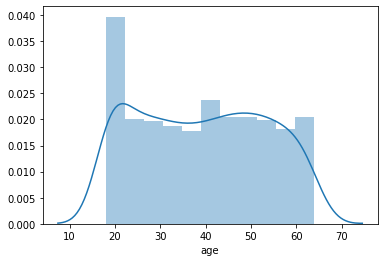

In [277]:
sns.distplot(DF_data['age'])

###### 2) 'BMI' Column

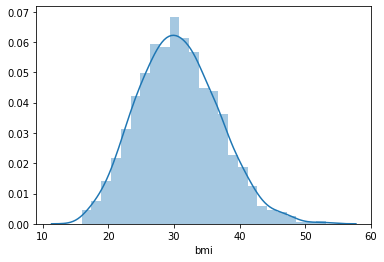

In [278]:
sns.distplot(DF_data['bmi'])

###### 3) 'CHARGES' Column

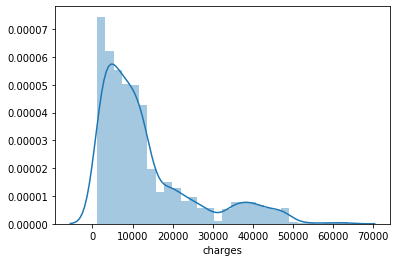

In [279]:
sns.distplot(DF_data['charges'])

-------------------------------------------------------------------------------------------------------------------------------

### Measure of skewness of ‘bmi’, ‘age’ and ‘charges’ columns

In [280]:
print( '\nSkewness for Age column : ', skew(DF_data['age'])) 



Skewness for Age column :  0.055610083072599126


In [281]:
print( '\nSkewness for BMI column : ', skew(DF_data['bmi'])) 



Skewness for BMI column :  0.28372857291709386


In [282]:
print( '\nSkewness for Charges column : ', skew(DF_data['charges'])) 



Skewness for Charges column :  1.5141797118745743


-------------------------------------------------------------------------------------------------------------------------------

### Checking the presence of outliers in ‘bmi’, ‘age’ and 'charges' columns

###### 1) 'AGE' Column

{'whiskers': [<matplotlib.lines.Line2D at 0x2020ac7bb88>,
 'caps': [<matplotlib.lines.Line2D at 0x2020ac90b88>,
 'boxes': [<matplotlib.lines.Line2D at 0x2020ac90408>],
 'medians': [<matplotlib.lines.Line2D at 0x2020ac96a48>],
 'fliers': [<matplotlib.lines.Line2D at 0x2020ac96c08>],
 'means': []}

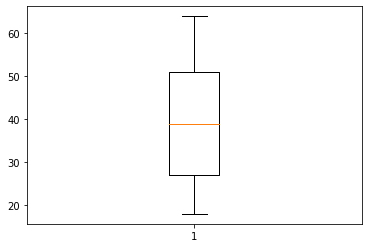

In [283]:
plt.boxplot(DF_data['age'])


###### No outliers are present in the 'AGE' column

###### 2) 'BMI' Column

{'whiskers': [<matplotlib.lines.Line2D at 0x2020acf2448>,
 'caps': [<matplotlib.lines.Line2D at 0x2020acf2e88>,
 'boxes': [<matplotlib.lines.Line2D at 0x2020acecbc8>],
 'medians': [<matplotlib.lines.Line2D at 0x2020acf7f88>],
 'fliers': [<matplotlib.lines.Line2D at 0x2020acfd708>],
 'means': []}

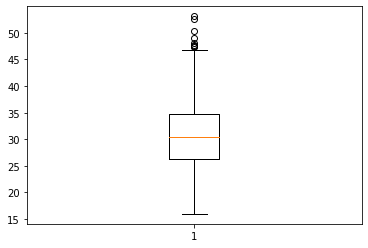

In [284]:
plt.boxplot(DF_data['bmi'])


In [285]:
Q1_BMI=DF_data['bmi'].quantile(q=0.25)

Q3_BMI=DF_data['bmi'].quantile(q=0.75)

IQR_BMI=Q3_BMI- Q1_BMI

In [286]:
Q3_BMI+1.5*IQR_BMI

47.290000000000006

###### We can see that less than 10 outliers are present in the 'BMI' column, i.e., BMI is above 47.29 for some of the people. All of these outliers are present above boxplot upper whisker.

###### 3) 'CHARGES' Column

{'whiskers': [<matplotlib.lines.Line2D at 0x2020ad5fa48>,
 'caps': [<matplotlib.lines.Line2D at 0x2020ad61388>,
 'boxes': [<matplotlib.lines.Line2D at 0x2020ad5f308>],
 'medians': [<matplotlib.lines.Line2D at 0x2020ad68308>],
 'fliers': [<matplotlib.lines.Line2D at 0x2020ad68c08>],
 'means': []}

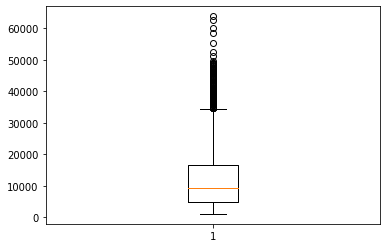

In [287]:
plt.boxplot(DF_data['charges'])


In [288]:
Q1_Charges=DF_data['charges'].quantile(q=0.25)

Q3_Charges=DF_data['charges'].quantile(q=0.75)

IQR_Charges=Q3_Charges- Q1_Charges

In [289]:
Q3_Charges + 1.5*IQR_Charges

34489.350562499996

###### We can see that the 'CHARGES' column contains many outliers, i.e, the charges are above 34489.35 for a significant number of people. All of these outliers are present above boxplot upper whisker.

-------------------------------------------------------------------------------------------------------------------------------

### Distribution of categorical columns (include children)

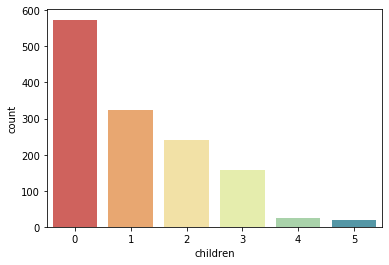

In [290]:
sns.countplot(DF_data['children'],palette='Spectral')

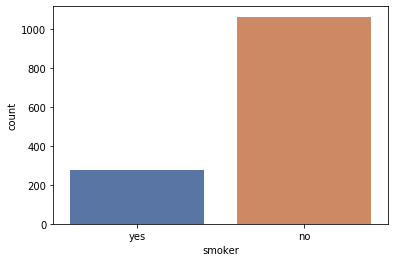

In [291]:
sns.countplot(DF_data['smoker'],palette='deep')

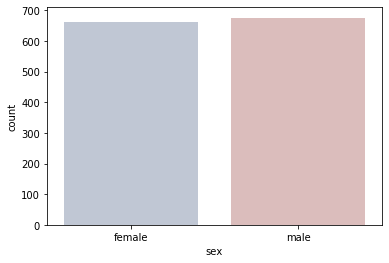

In [292]:
sns.countplot(DF_data['sex'],palette='vlag')

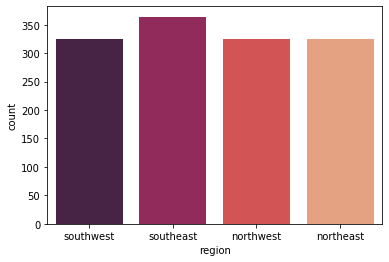

In [293]:
sns.countplot(DF_data['region'],palette='rocket')

-------------------------------------------------------------------------------------------------------------------------------

### Pair plot that includes all the columns of the data frame

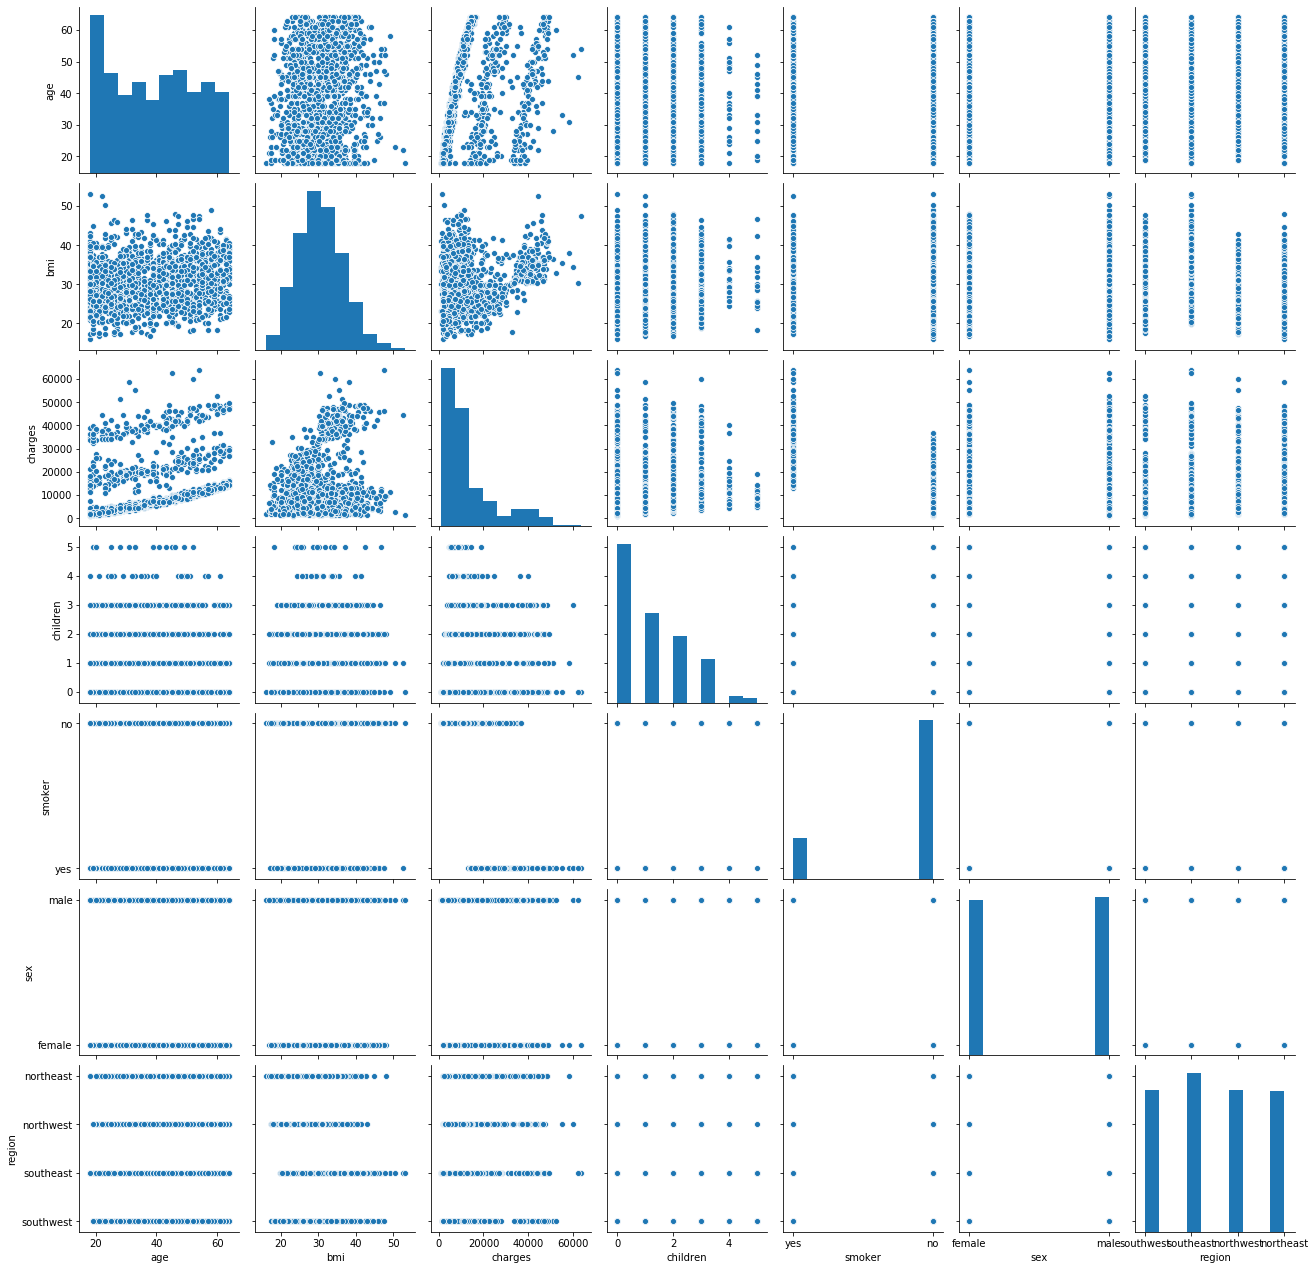

In [294]:
sns.pairplot(DF_data, vars=["age","bmi","charges","children","smoker","sex","region"])


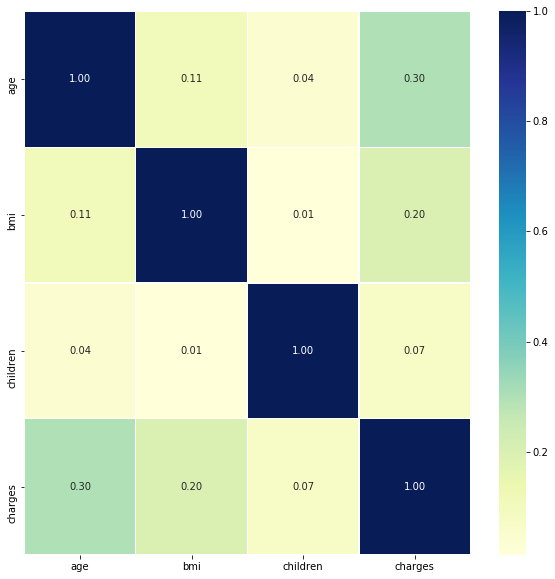

In [295]:
fig,ax = plt.subplots(figsize=(10, 10))   
sns.heatmap(data.corr(), ax=ax, annot=True, linewidths=0.05, fmt= '.2f',cmap="YlGnBu") # the color intensity is based on 
plt.show()

-------------------------------------------------------------------------------------------------------------------------------

### Do charges of people who smoke differ significantly from the people who don't?

##### Null and alternative hypotheses

In testing whether smoking has any effect on charges, the null hypothesis states that there is no difference in charges
due to smoking.The alternative hypthesis states that there is difference in charges due to smoking.

* $H_0$: $\mu{Smoker}$ - $\mu{Non-Smoker}$ =  0
* $H_A$: $\mu{Smoker}$ - $\mu{Non-Smoker}$ $\neq$  0

Let's select α = 0.05


Here population standard deviation is not known.

* We have two samples and we do not know the population standard deviation.
* Sample sizes for both samples are not same.
* The sample is not a large sample. So you use the t distribution and the $t_STAT$ test statistic for two sample unpaired test.

In [296]:
Smoker=DF_data[DF_data['smoker']=="yes"]
Non_Smoker=DF_data[DF_data['smoker']=="no"]

Two samples considered for testing are:
    
    
     Smoker['charges']     
        
     Non_Smoker['charges']

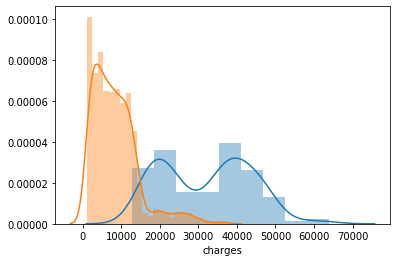

In [297]:
sns.distplot(Smoker['charges'])
sns.distplot(Non_Smoker['charges'])

In [298]:
t_stat, p_value  =  stats.ttest_ind(Smoker['charges'],Non_Smoker['charges'])
print('T-statistic %1.7f' % t_stat)
print('P Value %.300f' % p_value)    
stats.ttest_ind(Smoker['charges'],Non_Smoker['charges'])

T-statistic 46.6649212
P Value 0.000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000827143584217721865


Ttest_indResult(statistic=46.664921172723716, pvalue=8.271435842177219e-283)

In this example, p value is 8.27e-283 and it is less than 5% level of significance

So the statistical decision is to reject the null hypothesis at 5% level of significance.

So there is sufficient evidence to reject the null hypothesis that the charges of smokers and non-smokers is same.

#### Conclusion: Charges of people who smoke differ significantly from the people who don't.

-------------------------------------------------------------------------------------------------------------------------------

### Does bmi of males differ significantly from that of females?

##### Null and alternative hypotheses


In testing whether BMI is different for males and females, the null hypothesis states that there is no difference in BMI
for males and females.The alternative hypthesis states that there is difference in BMI for males and females.

* $H_0$: $\mu{Males}$ - $\mu{Females}$ =  0
* $H_A$: $\mu{Males}$ - $\mu{Females}$ $\neq$  0

Let's select α = 0.05


Here population standard deviation is not known.

* We have two samples and we do not know the population standard deviation.
* Sample sizes for both samples are not same.
* The sample is not a large sample. So you use the t distribution and the $t_STAT$ test statistic for two sample unpaired test.

In [299]:
BMI_Male=DF_data[DF_data['sex']=="male"].bmi
BMI_Female=DF_data[DF_data['sex']=="female"].bmi

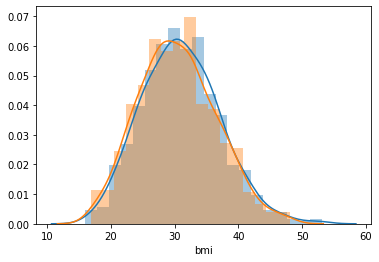

In [300]:
sns.distplot(BMI_Male)
sns.distplot(BMI_Female)

In [301]:
t_stat, p_value  =  stats.ttest_ind(BMI_Male,BMI_Female)
print('T-statistic %.7f' % t_stat)
print('P Value %.7f' % p_value)    
stats.ttest_ind(BMI_Male,BMI_Female)

T-statistic 1.6967526
P Value 0.0899764


Ttest_indResult(statistic=1.696752635752224, pvalue=0.08997637178984932)

In this example, p value is 0.0899 and it is more than 5% level of significance

So the statistical decision is to accept the null hypothesis at 5% level of significance.

So there is no sufficient evidence to reject the null hypothesis that the BMI of male and female is same.

#### Conclusion: BMI of males does not significantly differ from that of females.

-------------------------------------------------------------------------------------------------------------------------------

### Is the proportion of smokers significantly different in different genders?

##### Null and alternative hypotheses

In testing whether proportion of smokers is significantly different in different genders, the null hypothesis states that there is no difference in proportion of smokers in different genders.
The alternative hypthesis states that there is difference in proportion of smokers in different genders.

Null hypothesis: $H_0$: There is no difference in proportion of smokers in different genders.
                        
Alternative hypothesis: $H_A$: There is a significant difference in proportion of smokers in different genders.

Let's select α = 0.05


We use the chi-square test of independence to find out the difference of categorical variables 

In [302]:
Smoker=DF_data[DF_data['smoker']=="yes"]
Smoker_Male=Smoker[Smoker['sex']=="male"]
Smoker_Female=Smoker[Smoker['sex']=="female"]

In [303]:
pd.crosstab(data['sex'],data['smoker'] )

smoker,no,yes
sex,,
female,547,115
male,517,159


In [304]:
quality_array = np.array([[547,115],[517,159]])
chi_sq_Stat, p_value, deg_freedom, exp_freq = stats.chi2_contingency(quality_array)
print('Chi-square statistic %3.5f \n P value %1.6f \n Degrees of freedom %d' %(chi_sq_Stat, p_value,deg_freedom))

Chi-square statistic 7.39291 
 P value 0.006548 
 Degrees of freedom 1


In this example, p value is 0.006548 and is less than 5% level of signifcance.
So, we reject the null hypothesis.


#### Conclusion: We can conclude that there is a significant difference in proportion of smokers in different genders


-------------------------------------------------------------------------------------------------------------------------------

### Is the distribution of bmi across women with no children, one child and two children, the same ?

In [305]:
BMI_Women=DF_data[DF_data['sex']=='female']

###BMI of women with no children
BMI_W_0=BMI_Women[BMI_Women['children']==0].bmi

###BMI of women with one child
BMI_W_1=BMI_Women[BMI_Women['children']==1].bmi

###BMI of women with two children
BMI_W_2=BMI_Women[BMI_Women['children']==2].bmi

In [306]:
from tabulate import tabulate

l = [["BMI_Women_NoChildren",len(BMI_W_0),BMI_W_0.mean(),np.std(BMI_W_0,ddof =1)],
     ["BMI_Women_OneChild",len(BMI_W_1),BMI_W_1.mean(),np.std(BMI_W_1,ddof =1)],
     ["BMI_Women_TwoChildren",len(BMI_W_2),BMI_W_2.mean(),np.std(BMI_W_2,ddof =1)]   
    ]
table = tabulate(l, headers=['BMI_Women','Count', 'Mean', 'Std_Dev'], tablefmt='orgtbl')

print(table)




| BMI_Women             |   Count |    Mean |   Std_Dev |
|-----------------------+---------+---------+-----------|
| BMI_Women_NoChildren  |     289 | 30.3615 |   5.96693 |
| BMI_Women_OneChild    |     158 | 30.0527 |   5.78683 |
| BMI_Women_TwoChildren |     119 | 30.6498 |   6.6282  |


In [307]:
BMI_df = pd.DataFrame()

df1 = pd.DataFrame({'Children': '0', 'BMI':BMI_W_0})
df2 = pd.DataFrame({'Children': '1', 'BMI':BMI_W_1})
df3 = pd.DataFrame({'Children': '2', 'BMI':BMI_W_2})

BMI_df = BMI_df.append(df1) 
BMI_df = BMI_df.append(df2) 
BMI_df = BMI_df.append(df3) 


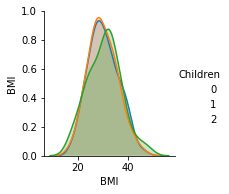

In [308]:
sns.pairplot(BMI_df,diag_kind='kde',hue='Children')

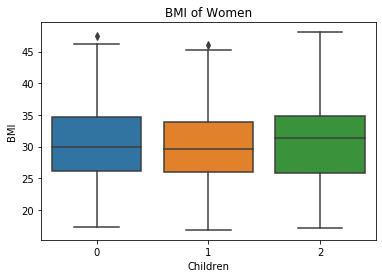

In [309]:
sns.boxplot(x = "Children", y = "BMI", data = BMI_df)
plt.title('BMI of Women')
plt.show()

#### Null hypothesis

* $H_0$: $\mu1$ = $\mu2$ = $\mu3$
* $H_A$: At least one $\mu$ differs

Let's select  $\alpha$ = 0.05 

Here we have three groups. Analysis of variance can determine 
whether the means of three or more groups are different. ANOVA uses F-tests to statistically test the equality of means.

In [310]:
f_oneway(BMI_W_0,BMI_W_1, BMI_W_2)

F_onewayResult(statistic=0.3344720147757968, pvalue=0.7158579926754841)

In [315]:
crit = stats.f.ppf(q = 1-0.05, dfn = 2, dfd = 563)
print('F critical value for 2 and 563 df with .95 confidence: %3.5f' %crit)

F critical value for 2 and 563 df with .95 confidence: 3.01173


In [316]:
p_value = 1 -stats.f.cdf(0.334472, dfn = 2, dfd = 563)
print('P value for 2 and 563 df with .95 confidence for the calculated F value: %3.9f' % p_value)

P value for 2 and 563 df with .95 confidence for the calculated F value: 0.715858003


In [313]:
print(pairwise_tukeyhsd(BMI_df['BMI'],BMI_df['Children'],alpha=0.05))

Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
     0      1  -0.3089 0.8494 -1.7186 1.1008  False
     0      2   0.2883 0.8942 -1.2636 1.8402  False
     1      2   0.5971 0.6797 -1.1323 2.3265  False
---------------------------------------------------


In [314]:
mod = ols('BMI ~ Children', data = BMI_df).fit()
aov_table = sm.stats.anova_lm(mod, typ=2)
print(aov_table)

                sum_sq     df         F    PR(>F)
Children     24.590123    2.0  0.334472  0.715858
Residual  20695.661583  563.0       NaN       NaN


In this example, calculated value of F ( = 0.334472) is less than Critical value of F( = 3.01173)

In this example, p value is 0.715858 and it is more than our chosen level of signifance at 5%

So the statistical decision is not to reject the null hypothesis at 5% level of significance.

So there is sufficient evidence to accept the null hypothesis that the distribution of bmi across women with no
children, one child and two children, is the same.

#### Conclusion: The distribution of bmi across women with no children, one child and two children, is the same.